# Kernels en SVM

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import sklearn
import sklearn.datasets
import sklearn.linear_model
import sklearn.neural_network

import mlutils
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
def load_dataset_disks(size, seed=39):    
    def get_sample_disk(from_, to, size):
        length = np.random.uniform(from_, to, size)
        angle = np.pi * np.random.uniform(0, 2, size)
        x = length * np.cos(angle)
        y = length * np.sin(angle)
        return np.array(list(zip(x,y)))

    np.random.seed(seed)
    size1 = int(size / 2)
    size2 = size - size1
    X = np.concatenate((get_sample_disk(0, 1, size1), get_sample_disk(1, 2, size2)))
    Y = np.concatenate((np.ones(size1), -np.ones(size2)))
    return X, Y

# SVMs (kernels)

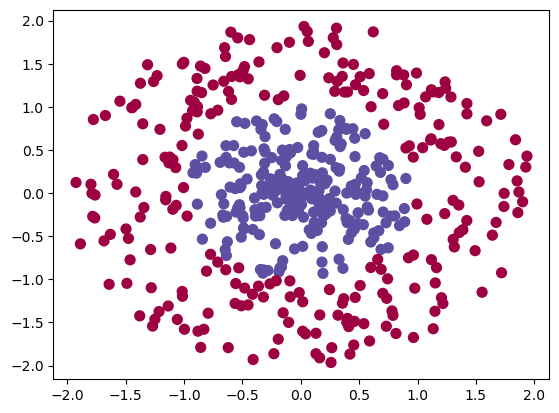

In [3]:
X, Y = load_dataset_disks(500)
plt.scatter(X[:, 0], X[:, 1], c=Y, s=50, cmap=plt.cm.Spectral);

### Probemos utilizar algunos kerneles

#### Sigmoide

$$tanh(\gamma \cdot \langle x \;,\; x^´\rangle + r)$$

In [4]:
clf = sklearn.svm.SVC(kernel="sigmoid", gamma="auto")
clf.fit(X, Y)

SVC(gamma='auto', kernel='sigmoid')

Accuracy: 65 


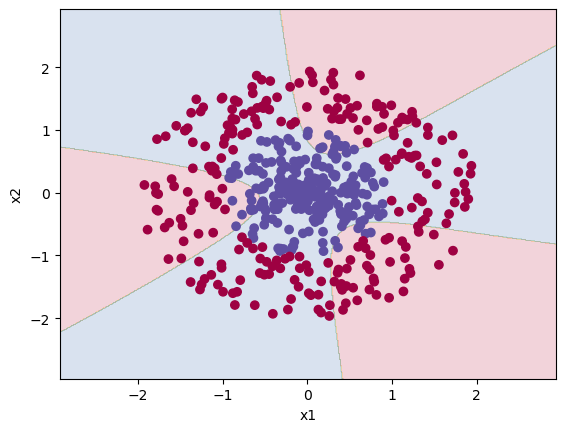

In [5]:
mlutils.plot_decision_boundary(lambda x: clf.predict(x), X.T, Y.T)
predictions = clf.predict(X)
print ('Accuracy: %d ' % ((np.sum(Y == predictions))/float(Y.size)*100))

#### RBF 

$$exp(-\gamma \cdot {\| x \; - \; x^´\|}²)$$

In [6]:
clf = sklearn.svm.SVC(kernel="rbf", gamma="auto")
clf.fit(X, Y)

SVC(gamma='auto')

Accuracy: 99 


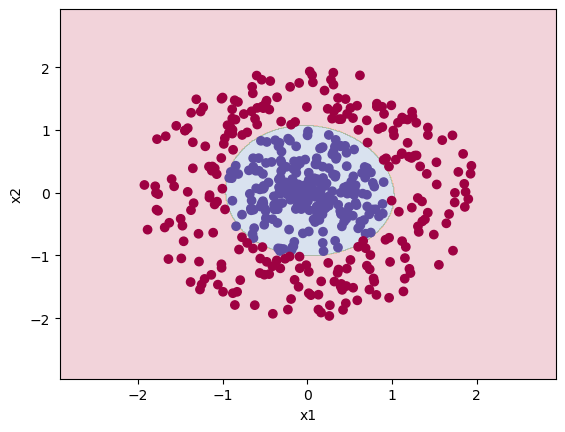

In [7]:
mlutils.plot_decision_boundary(lambda x: clf.predict(x), X.T, Y.T)
predictions = clf.predict(X)
print ('Accuracy: %d ' % ((np.sum(Y == predictions))/float(Y.size)*100))

#### Polinomial

$$(\gamma \cdot \langle x \;,\; x^´\rangle + r)^d$$

In [8]:
clf = sklearn.svm.SVC(kernel="poly", degree=6, gamma="auto")
clf.fit(X, Y);

Accuracy: 95 


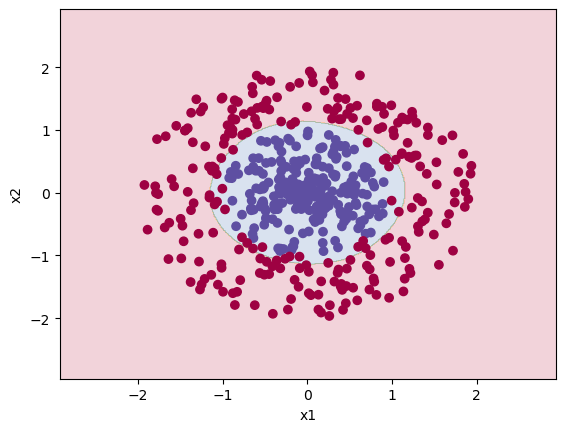

In [9]:
mlutils.plot_decision_boundary(lambda x: clf.predict(x), X.T, Y.T)
predictions = clf.predict(X)
print ('Accuracy: %d ' % ((np.sum(Y == predictions))/float(Y.size)*100))

In [10]:
sklearn.svm.SVC?

Init signature:
sklearn.svm.SVC(
    *,
    C=1.0,
    kernel='rbf',
    degree=3,
    gamma='scale',
    coef0=0.0,
    shrinking=True,
    probability=False,
    tol=0.001,
    cache_size=200,
    class_weight=None,
    verbose=False,
    max_iter=-1,
    decision_function_shape='ovr',
    break_ties=False,
    random_state=None,
)
Docstring:     
C-Support Vector Classification.

The implementation is based on libsvm. The fit time scales at least
quadratically with the number of samples and may be impractical
beyond tens of thousands of samples. For large datasets
consider using :class:`~sklearn.svm.LinearSVC` or
:class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
:class:`~sklearn.kernel_approximation.Nystroem` transformer or
other :ref:`kernel_approximation`.

The multiclass support is handled according to a one-vs-one scheme.

For details on the precise mathematical formulation of the provided
kernel functions and how `gamma`, `coef0` and `degree` affect each
ot

Un ejemplo interesante de uso de SVM: https://www.kaggle.com/pierra/credit-card-dataset-svm-classification

## Usemos conjunto de entrenamiento y de prueba

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Dividimos el conjunto de datos

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

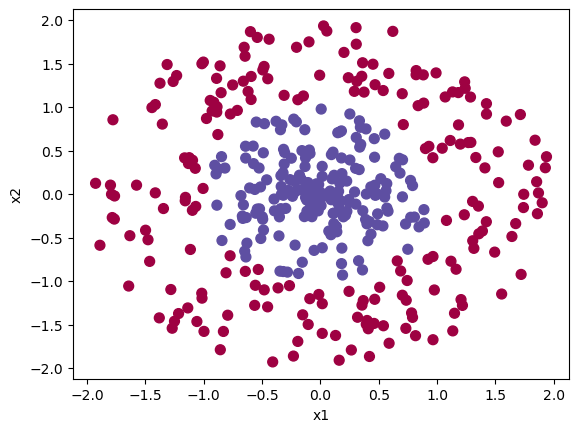

In [13]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap=plt.cm.Spectral)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

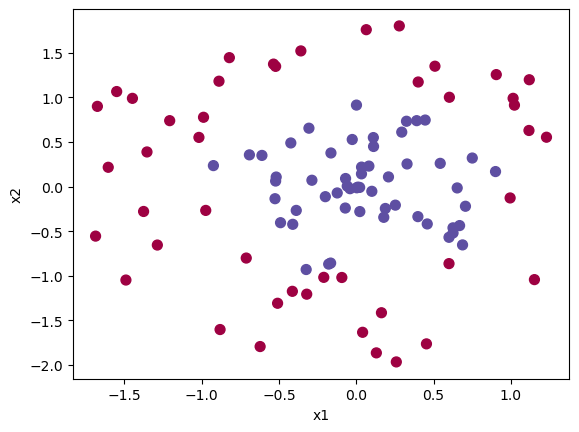

In [14]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=50, cmap=plt.cm.Spectral)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

## Reporte de clasificación usando el conjunto de datos de prueba

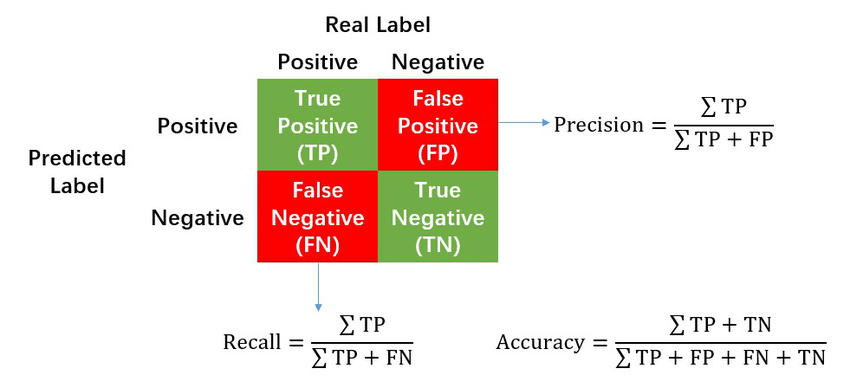

In [17]:
from IPython.display import Image
Image('./images/confusion_matrix.png',width=500) 

              precision    recall  f1-score   support

        -1.0       0.62      0.33      0.43        45
         1.0       0.61      0.84      0.70        55

    accuracy                           0.61       100
   macro avg       0.62      0.58      0.57       100
weighted avg       0.61      0.61      0.58       100



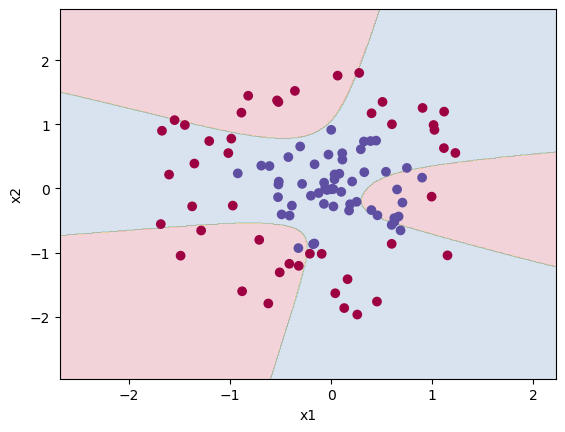

In [18]:
clf = sklearn.svm.SVC(kernel="sigmoid", gamma="auto").fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

mlutils.plot_decision_boundary(lambda x: clf.predict(x), X_test.T, y_test.T)

[LibSVM]*
optimization finished, #iter = 84
obj = -56.869665, rho = -2.308156
nSV = 81, nBSV = 75
Total nSV = 81
              precision    recall  f1-score   support

        -1.0       1.00      0.98      0.99        45
         1.0       0.98      1.00      0.99        55

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



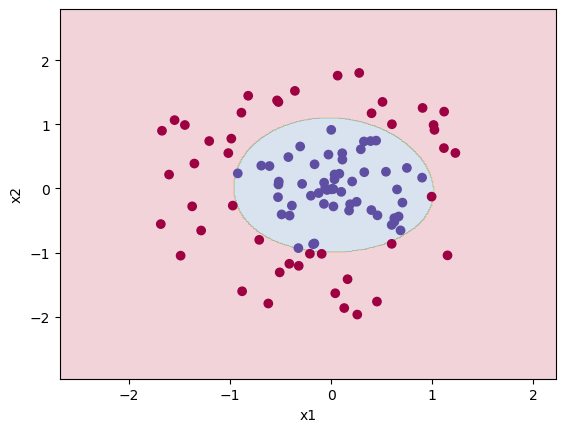

In [19]:
clf = sklearn.svm.SVC(kernel="rbf", gamma="auto", verbose=2).fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

mlutils.plot_decision_boundary(lambda x: clf.predict(x), X_test.T, y_test.T)

## Referencias:
 * Scikit: [Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html#support-vector-machines)